#### This notebook aims to show the implementation of ANN for Regression problem.

In [1]:
# import dependancies

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

#### Dataset info

(Dataset Link)[https://www.kaggle.com/datasets/rinichristy/combined-cycle-power-plant-data-set-uci-data/data]

The dataset contains 9568 data points collected from a Combined Cycle Power Plant over 6 years (2006-2011), when the power plant was set to work with full load. Features consist of hourly average ambient variables Average Temperature (AT), Ambient Pressure (AP), Relative Humidity (RH) and Exhaust Vacuum (V) to predict the net hourly electrical energy output (EP) of the plant. 

**Attribute Information:**

Features consist of hourly average ambient variables

- Temperature (T) in the range 1.81°C and 37.11°C,
- Ambient Pressure (AP) in the range 992.89-1033.30 milibar,
- Relative Humidity (RH) in the range 25.56% to 100.16%
- Exhaust Vacuum (V) in teh range 25.36-81.56 cm Hg
- Net hourly electrical energy output (EP) 420.26-495.76 MW 

In [2]:
# Reading Dataset

df = pd.read_csv("data_PowerPlantData.csv")
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


In [3]:
df.tail()

,AT,V,AP,RH,PE
9563,16.65,49.69,1014.01,91.00,460.03
9564,13.19,39.18,1023.67,66.78,469.62
9565,31.32,74.33,1012.92,36.48,429.57
9566,24.48,69.45,1013.86,62.39,435.74
9567,21.60,62.52,1017.23,67.87,453.28


In [4]:
df.sample(10)

,AT,V,AP,RH,PE
8928,28.07,68.08,1013.13,44.67,437.65
389,15.00,40.66,1016.28,89.62,456.63
9208,14.79,44.06,1018.53,74.79,465.77
3204,22.78,59.92,1011.28,88.78,440.87
3319,20.04,48.92,1011.14,68.92,447.89
2270,23.22,63.07,1012.91,77.59,446.62
1945,28.84,74.67,1016.52,67.43,428.98
8830,11.75,35.76,1018.99,57.92,473.01
1734,15.27,38.73,1002.83,77.77,465.99
6584,14.43,35.85,1021.99,78.25,464.60


In [5]:
df.columns.to_list()

['AT', 'V', 'AP', 'RH', 'PE']

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
# 5 Point summary
# Stats of the dataset

df.describe()

All the values are numerical and continuous values,so there is not need to transform the data into numerical values as seen

#### EDA

In [ ]:
df.isnull().sum()

There is no any missing value in the data set as seen

In [ ]:
df.corr()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

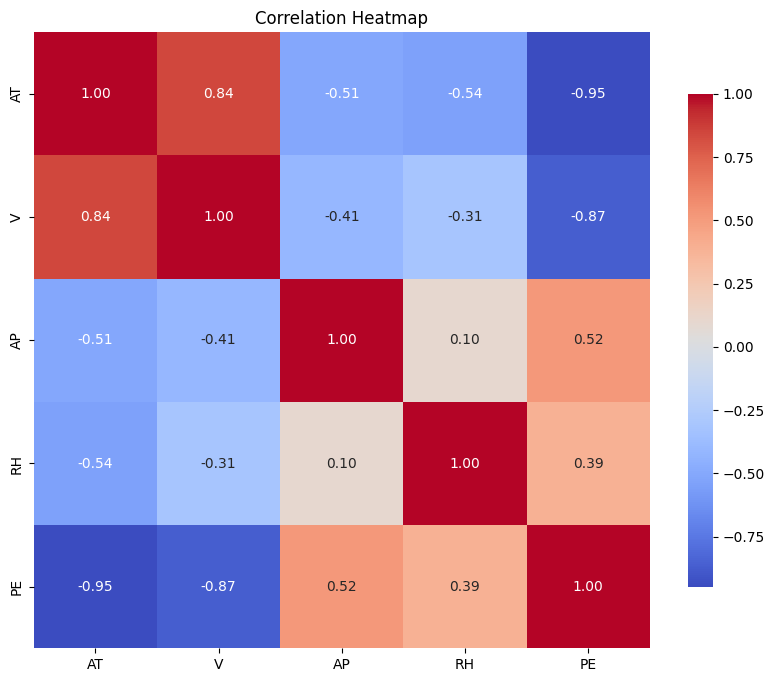

In [4]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"shrink": .8})
plt.title("Correlation Heatmap")
plt.show() 

In [5]:
df.corr()["PE"].sort_values(ascending=False)

PE    1.000000
AP    0.518429
RH    0.389794
V    -0.869780
AT   -0.948128
Name: PE, dtype: float64

**Observation**

- There is strong positive correlation between Net Hourly Electrical Energy Output and Ambient Pressure
- Very strong negative correlation between Net Hourly Electrical Energy Output and Average Temperature or Exhaust Vacuum.

Time taken: 12.065954446792603 seconds


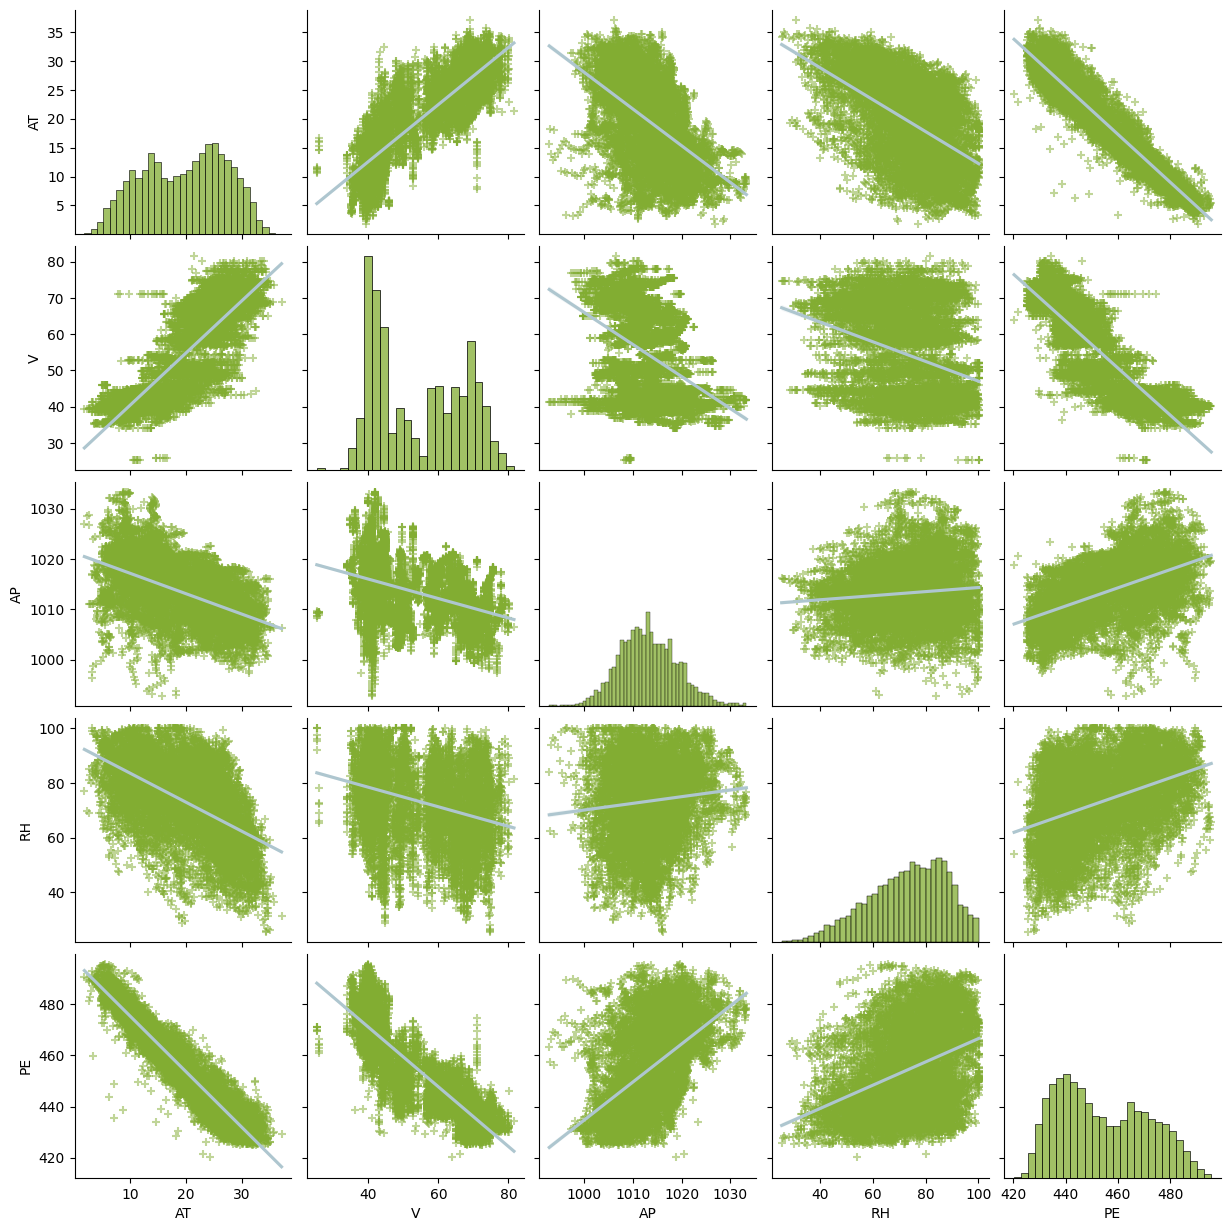

In [6]:
import time
start = time.time()

sns.pairplot(df,
                 markers="+",
                 kind='reg',
                 diag_kind="auto",
                 plot_kws={'line_kws':{'color':'#aec6cf'},
                           'scatter_kws': {'alpha': 0.5,
                                           'color': '#82ad32'}},
               
                 diag_kws= {'color': '#82ad32'})

end = time.time()

print("Time taken:", end - start, "seconds")

In [7]:
# Splitting the dataset into X and y
X = df.drop("PE", axis=1).values
y = df["PE"].values
print(X)
print(y)

[[  14.96   41.76 1024.07   73.17]
 [  25.18   62.96 1020.04   59.08]
 [   5.11   39.4  1012.16   92.14]
 ...
 [  31.32   74.33 1012.92   36.48]
 [  24.48   69.45 1013.86   62.39]
 [  21.6    62.52 1017.23   67.87]]
[463.26 444.37 488.56 ... 429.57 435.74 453.28]


In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(7176, 4)
(2392, 4)
(7176,)
(2392,)


In [9]:
# Feature Scaling
# Standardization of the dataset

from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_test)
print(X_train)
print(X_test)

[[-1.56080357 -1.25245691  1.32870923  0.89387562]
 [-1.81519199 -1.24300868 -0.06957792  1.3919209 ]
 [ 0.66139369  0.7025391   0.09195706  0.61991656]
 ...
 [ 1.09614215  1.17652524 -0.06452995 -1.88533998]
 [-0.99415    -1.00680296  0.27368391  1.10019891]
 [-1.0627945  -1.08160144  0.81549914  1.66656315]]
[[-8.23787952e-04 -4.90299789e-01  2.63587971e-01  1.12989824e-01]
 [ 1.15940276e+00  1.17652524e+00 -3.92901118e-02 -2.13197146e+00]
 [ 1.12171559e+00  1.01433065e+00 -9.96721385e-01  1.35535083e-01]
 ...
 [-3.87117315e-01 -3.85581919e-01  9.02997257e-01  1.54085625e+00]
 [-9.95495971e-01 -7.64298424e-01  5.42908870e-01  5.35884234e-01]
 [ 1.86266109e-01  7.53717005e-01  2.68635939e-01 -1.08363632e-01]]


In [10]:
# Model Building

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, r2_score

In [13]:
model = Sequential()                         
model.add(Dense(units=64, input_shape=(X_train.shape[1],), activation="relu"))  
model.add(Dense(units=32, activation="relu"))  
model.add(Dense(units=1))
model.compile(optimizer="adam", loss="mean_squared_error", metrics=["mae"])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 64)                  │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

In [15]:
import time
start = time.time()

model.fit(x=X_train, y=y_train, 
            epochs=100, 
            batch_size=32,
            validation_data=(X_test,y_test),
            callbacks=EarlyStopping(monitor='val_loss',patience=4,restore_best_weights=True)
)

end = time.time()
print("Time taken:", end - start, "seconds")

Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 173048.8125 - mae: 412.8770 - val_loss: 87719.4609 - val_mae: 291.4308
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 29985.1328 - mae: 146.6744 - val_loss: 12681.1719 - val_mae: 95.0893
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8437.7461 - mae: 76.6887 - val_loss: 5149.0015 - val_mae: 60.1435
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3271.0791 - mae: 46.8809 - val_loss: 1939.4858 - val_mae: 36.1024
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1331.7216 - mae: 29.1383 - val_loss: 902.7033 - val_mae: 23.7988
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 663.8383 - mae: 19.9351 - val_loss: 485.5003 - val_mae: 16.8331
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 377.0569 - mae: 14.7611 - val_loss: 292.9365 - val_mae: 13.0213
Epoch 8/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 232.6810 - mae: 11.5707 - val_loss: 189.5613 - 

In [16]:
model.history.history

{'loss': [173048.8125,
  29985.1328125,
  8437.74609375,
  3271.0791015625,
  1331.7215576171875,
  663.8382568359375,
  377.0569152832031,
  232.68099975585938,
  152.95838928222656,
  105.34862518310547,
  76.81974792480469,
  58.79745864868164,
  47.47256851196289,
  39.77574157714844,
  34.61473846435547,
  30.757226943969727,
  28.210466384887695,
  26.341049194335938,
  24.855131149291992,
  23.838518142700195,
  22.801870346069336,
  22.20303726196289,
  21.524900436401367,
  21.0677433013916,
  20.78201675415039,
  20.74872589111328,
  20.245216369628906,
  20.091951370239258,
  20.231210708618164,
  19.879262924194336,
  19.755847930908203,
  19.420072555541992,
  19.580692291259766,
  19.715084075927734,
  19.873382568359375,
  19.8762264251709,
  19.64449119567871,
  19.291624069213867,
  19.323896408081055],
 'mae': [412.8770446777344,
  146.67440795898438,
  76.68867492675781,
  46.88086700439453,
  29.138301849365234,
  19.935110092163086,
  14.761140823364258,
  11.57065

In [17]:
pd.DataFrame(model.history.history)

,loss,mae,val_loss,val_mae
0,173048.812500,412.877045,87719.460938,291.430817
1,29985.132812,146.674408,12681.171875,95.089325
2,8437.746094,76.688675,5149.001465,60.143513
3,3271.079102,46.880867,1939.485840,36.102425
4,1331.721558,29.138302,902.703308,23.798782
5,663.838257,19.935110,485.500305,16.833082
6,377.056915,14.761141,292.936523,13.021339
7,232.681000,11.570652,189.561340,10.366179
8,152.958389,9.326396,129.189697,8.565680
9,105.348625,7.753454,90.264870,6.970758


<Axes: >

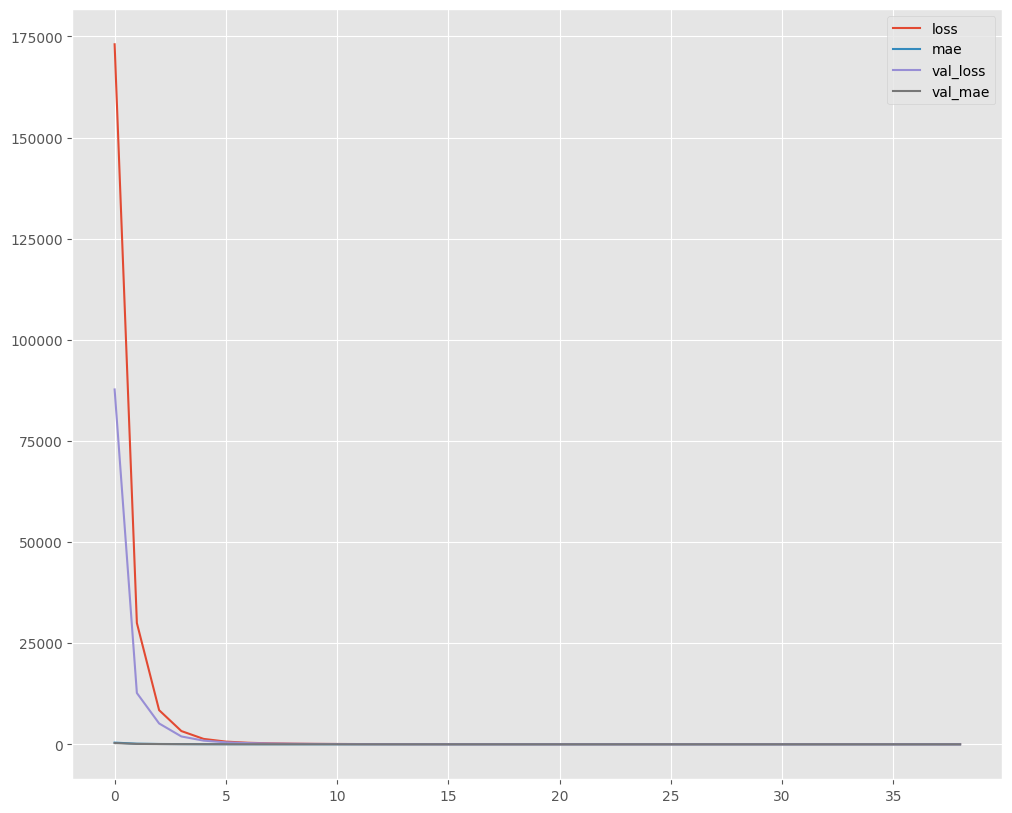

In [18]:
plt.style.use("ggplot")
pd.DataFrame(model.history.history).plot(figsize=(12,10))

our deep learning model performs very well

In [19]:
model.evaluate(X_train,y_train)

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 18.6198 - mae: 3.4059


[18.619752883911133, 3.4058964252471924]

In [20]:
model.evaluate(X_test,y_test)

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 18.8738 - mae: 3.3986


[18.873802185058594, 3.3985660076141357]

In [21]:
predictions = model.predict(X_test)
predictions_df = pd.DataFrame(np.ravel(predictions),columns=["Predictions"])
comparison_df = pd.concat([pd.DataFrame(y_test,columns=["Real Values"]), predictions_df],axis=1)
comparison_df 

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


,Real Values,Predictions
0,455.27,454.912231
1,436.31,440.565979
2,440.68,433.329895
3,434.40,441.076508
4,482.06,480.521973
...,...,...
2387,479.78,481.910980
2388,434.52,433.234375
2389,459.38,457.019501
2390,475.24,469.528015


As seen above in the comparison dataframe, the predictions of the model is very close to the actual values.

In [22]:
print(y_test.shape)       
print(predictions.shape)

(2392,)
(2392, 1)


In [23]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Test MSE: 18.87
R² Score: 0.94


In [24]:
from sklearn import metrics
print("MAE:",metrics.mean_absolute_error(y_test,predictions))
print ("MSE:",metrics.mean_squared_error(y_test,predictions))
print("RMSE:",np.sqrt(metrics.mean_squared_error(y_test,predictions)))

MAE: 3.3985655176679423
MSE: 18.873802148241822
RMSE: 4.344398939812252
